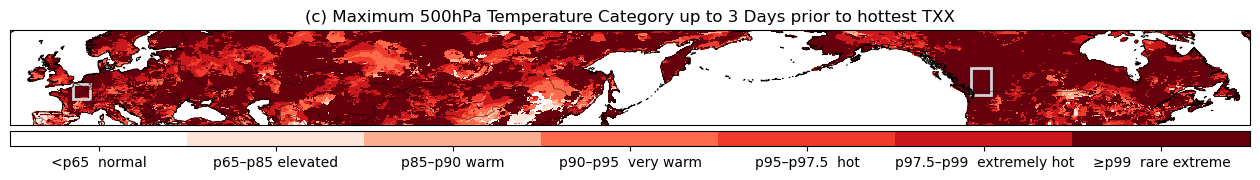

In [75]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118  # example: 235–245
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# 1) Hottest TXX year per grid cell
# -----------------------
txx = ds_band["txx"]                 # (year, lat, lon)
i_hot = txx.argmax("year")           # (lat, lon)

t500_hot = ds_band["t500_premax_3d"].isel(year=i_hot)  # (lat, lon)

# -----------------------
# 2) Quantiles per grid cell
# -----------------------
ps = np.array([0.65, 0.85, 0.90, 0.95, 0.975, 0.99])

if "t_quantiles" in dsq_band.data_vars:
    tQ = dsq_band["t_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_band[first_name]

tQ = tQ.sortby("quantile").squeeze(drop=True)

t65  = tQ.sel(quantile=ps[0])
t85  = tQ.sel(quantile=ps[1])
t90  = tQ.sel(quantile=ps[2])
t95  = tQ.sel(quantile=ps[3])
t975 = tQ.sel(quantile=ps[4])
t99  = tQ.sel(quantile=ps[5])

# -----------------------
# 3) Category codes 0..6
# -----------------------
cat = xr.full_like(t500_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(t500_hot < t65, 0, cat)
cat = xr.where((t500_hot >= t65)  & (t500_hot < t85),  1, cat)
cat = xr.where((t500_hot >= t85)  & (t500_hot < t90),  2, cat)
cat = xr.where((t500_hot >= t90)  & (t500_hot < t95),  3, cat)
cat = xr.where((t500_hot >= t95)  & (t500_hot < t975), 4, cat)
cat = xr.where((t500_hot >= t975) & (t500_hot < t99),  5, cat)
cat = xr.where(t500_hot >= t99, 6, cat)

labels = [
    "<p65  normal",
    "p65–p85 elevated",
    "p85–p90 warm",
    "p90–p95  very warm",
    "p95–p97.5  hot",
    "p97.5–p99  extremely hot",
    "≥p99  rare extreme",
]

# -----------------------
# 4) Land-only mask (global band)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

cat_land = cat.where(land_mask)

# -----------------------
# 5) Plot (with horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

cmap = ListedColormap([
    "#ffffff",
    "#fee5d9",
    "#fcae91",
    "#fb6a4a",
    "#ef3b2c",
    "#cb181d",
    "#67000d",
])

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# IMPORTANT: disable xarray's auto-colorbar, we add our own horizontal one
im = cat_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmap, vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("(c) Maximum 500hPa Temperature Category up to 3 Days prior to hottest TXX")

# ---- Horizontal colorbar below plot ----
# leave extra room at bottom for the bar
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,       # distance from plot
    fraction=0.06,  # thickness
    aspect=80       # length/thickness ratio
)
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

plt.savefig("maxT500_quantile_TXX_map.png", dpi=300, bbox_inches="tight")
plt.show()


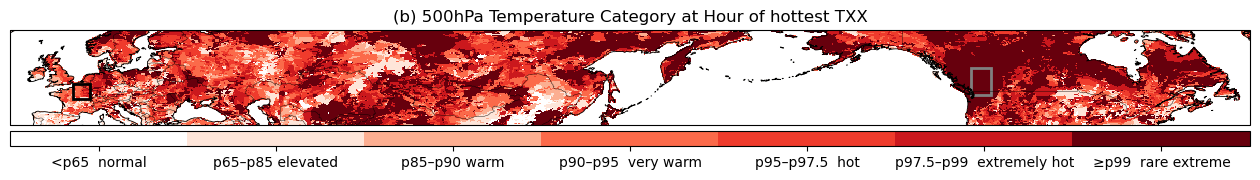

In [76]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# 1) Hottest TXX year per grid cell
# -----------------------
txx = ds_band["txx"]                 # (year, lat, lon)
i_hot = txx.argmax("year")           # (lat, lon)

t500_hot = ds_band["t_at_tasmax"].isel(year=i_hot)  # (lat, lon)

# -----------------------
# 2) Quantiles per grid cell
# -----------------------
ps = np.array([0.65, 0.85, 0.90, 0.95, 0.975, 0.99])

if "t_quantiles" in dsq_band.data_vars:
    tQ = dsq_band["t_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_band[first_name]

tQ = tQ.sortby("quantile").squeeze(drop=True)

t65  = tQ.sel(quantile=ps[0])
t85  = tQ.sel(quantile=ps[1])
t90  = tQ.sel(quantile=ps[2])
t95  = tQ.sel(quantile=ps[3])
t975 = tQ.sel(quantile=ps[4])
t99  = tQ.sel(quantile=ps[5])

# -----------------------
# 3) Category codes 0..6
# -----------------------
cat = xr.full_like(t500_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(t500_hot < t65, 0, cat)
cat = xr.where((t500_hot >= t65)  & (t500_hot < t85),  1, cat)
cat = xr.where((t500_hot >= t85)  & (t500_hot < t90),  2, cat)
cat = xr.where((t500_hot >= t90)  & (t500_hot < t95),  3, cat)
cat = xr.where((t500_hot >= t95)  & (t500_hot < t975), 4, cat)
cat = xr.where((t500_hot >= t975) & (t500_hot < t99),  5, cat)
cat = xr.where(t500_hot >= t99, 6, cat)

labels = [
    "<p65  normal",
    "p65–p85 elevated",
    "p85–p90 warm",
    "p90–p95  very warm",
    "p95–p97.5  hot",
    "p97.5–p99  extremely hot",
    "≥p99  rare extreme",
]

# -----------------------
# 4) Land-only mask (global band)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

cat_land = cat.where(land_mask)

# -----------------------
# 5) Plot RHS only for the entire longitude band
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

cmap = ListedColormap([
    "#ffffff",
    "#fee5d9",
    "#fcae91",
    "#fb6a4a",
    "#ef3b2c",
    "#cb181d",
    "#67000d",
])

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# IMPORTANT: disable xarray auto-colorbar
im = cat_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmap, vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=False
)

# -----------------------
# choose a tight lon-extent
# -----------------------
lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangle
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="black",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

# draw rectangle box
rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="gray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("(b) 500hPa Temperature Category at Hour of hottest TXX")

# ---- Horizontal colorbar below plot ----
# leave extra room at bottom for the bar
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,       # distance from plot
    fraction=0.06,  # thickness
    aspect=80       # length/thickness ratio
)
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

plt.savefig("T500_quantile_TXX_map.png", dpi=300, bbox_inches="tight")
plt.show()


Available quantiles in file: [0.01  0.025 0.05  0.1   0.15  0.35  0.5   0.65  0.9  ]


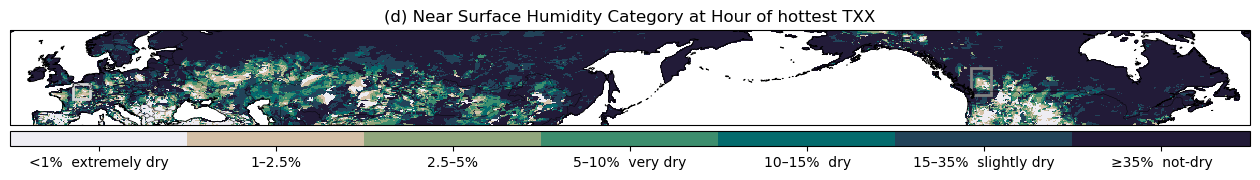

In [77]:
# --- Use precomputed q-quantiles (per grid cell) to classify q_at_tasmax at hottest TXX ---

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_q_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_q_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_q_quant)

# (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat', 0)}, lon={ds_band.dims.get('lon', 0)}"
    )

# -----------------------
# 1) Hottest TXX year per grid cell
# -----------------------
txx = ds_band["txx"]                 # (year, lat, lon)
i_hot = txx.argmax("year")           # (lat, lon)

q_hot = ds_band["q_at_tasmax"].isel(year=i_hot)  # (lat, lon)

# -----------------------
# 2) Quantiles per grid cell
# -----------------------
if "q_quantiles" in dsq_band.data_vars:
    qQ = dsq_band["q_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 'q_quantiles' not found; using '{first_name}' instead.")
    qQ = dsq_band[first_name]

qQ = qQ.sortby("quantile").squeeze(drop=True)

# read quantiles directly from file
ps = qQ["quantile"].values
print("Available quantiles in file:", ps)

# pick thresholds (same names as before)
q01  = qQ.sel(quantile=ps[0])
q025 = qQ.sel(quantile=ps[1])
q05  = qQ.sel(quantile=ps[2])
q10  = qQ.sel(quantile=ps[3])
q15  = qQ.sel(quantile=ps[4])
q35  = qQ.sel(quantile=ps[5])
q50  = qQ.sel(quantile=ps[6])
q65  = qQ.sel(quantile=ps[7])
q90  = qQ.sel(quantile=ps[8])

# -----------------------
# 3) Category codes 0..6 (dry-focused)
# -----------------------
# 0: <1%       extremely dry
# 1: 1–2.5%
# 2: 2.5–5%
# 3: 5–10%     very dry
# 4: 10–15%    dry
# 5: 15–35%    slightly dry
# 6: >=35%     not-dry (near-normal to wet)
cat = xr.full_like(q_hot, fill_value=np.nan, dtype=np.float32)

cat = xr.where(q_hot < q01, 0, cat)
cat = xr.where((q_hot >= q01)  & (q_hot < q025), 1, cat)
cat = xr.where((q_hot >= q025) & (q_hot < q05),  2, cat)
cat = xr.where((q_hot >= q05)  & (q_hot < q10),  3, cat)
cat = xr.where((q_hot >= q10)  & (q_hot < q15),  4, cat)
cat = xr.where((q_hot >= q15)  & (q_hot < q35),  5, cat)
cat = xr.where(q_hot >= q35, 6, cat)

cat = cat.rename("q_dry_category_at_hottest_txx")
cat.attrs["codes"] = "0:<p01, 1:p01-02.5, 2:p02.5-05, 3:p05-10, 4:p10-15, 5:p15-35, 6:>=p35"

labels = [
    "<1%  extremely dry",
    "1–2.5%",
    "2.5–5%",
    "5–10%  very dry",
    "10–15%  dry",
    "15–35%  slightly dry",
    "≥35%  not-dry",
]

# -----------------------
# 4) Land-only mask (global band)
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

cat_land = cat.where(land_mask)

# -----------------------
# 5) Plot RHS only for the entire longitude band
# -----------------------
# Use central_longitude=135 so 0..360 displays nicely without a big seam
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

import cmocean
cmap = cmocean.cm.rain

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# IMPORTANT: disable xarray auto-colorbar
im = cat_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmap, vmin=-0.5, vmax=6.5, levels=8,
    add_colorbar=False
)

# Draw rectangle
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False,
    edgecolor="lightgray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

# draw rectangle box
rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False,
    edgecolor="gray",
    linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

# -----------------------
# lon extent (keep your original choice)
# -----------------------
lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

ax.set_title("(d) Near Surface Humidity Category at Hour of hottest TXX")

# ---- Horizontal colorbar below plot ----
# leave extra room at bottom for the bar
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,       # distance from plot
    fraction=0.06,  # thickness
    aspect=80       # length/thickness ratio
)
cbar.set_ticks(np.arange(0, 7))
cbar.set_ticklabels(labels)

plt.savefig("humidity_quantile_TXX_map.png", dpi=300, bbox_inches="tight")
plt.show()


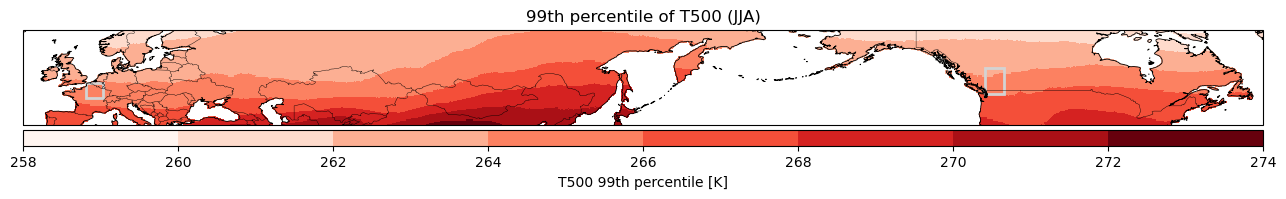

In [65]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# Read t99 quantile field
# -----------------------
if "t_quantiles" in dsq_band.data_vars:
    tQ = dsq_band["t_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_band[first_name]

tQ = tQ.sortby("quantile").squeeze(drop=True)

# select 99th percentile
t99 = tQ.sel(quantile=0.99)

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

t99_land = t99.where(land_mask)

# -----------------------
# Plot (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = t99_land.plot(
    ax=ax, transform=data_crs,
    x="lon", y="lat",
    cmap="Reds", levels =8,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("99th percentile of T500 (JJA)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("T500 99th percentile [K]")

plt.savefig("t500_p99_map.png", dpi=300, bbox_inches="tight")
plt.show()


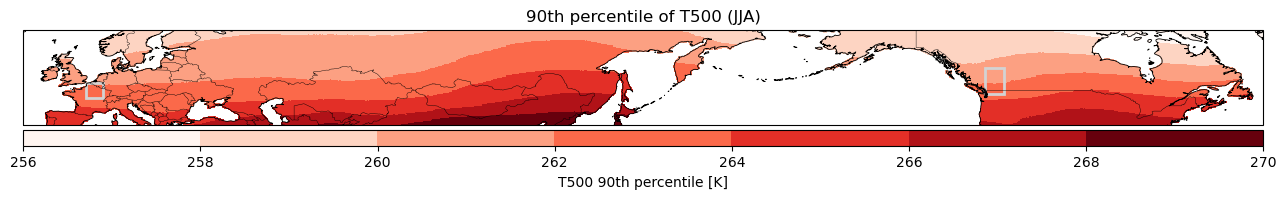

In [66]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# Read t99 quantile field
# -----------------------
if "t_quantiles" in dsq_band.data_vars:
    tQ = dsq_band["t_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 't_quantiles' not found; using '{first_name}' instead.")
    tQ = dsq_band[first_name]

tQ = tQ.sortby("quantile").squeeze(drop=True)

# select 99th percentile
t99 = tQ.sel(quantile=0.90)

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

t99_land = t99.where(land_mask)

# -----------------------
# Plot (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = t99_land.plot(
    ax=ax, transform=data_crs,
    x="lon", y="lat",
    cmap="Reds", levels =8,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("90th percentile of T500 (JJA)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("T500 90th percentile [K]")

plt.savefig("t500_p90_map.png", dpi=300, bbox_inches="tight")
plt.show()


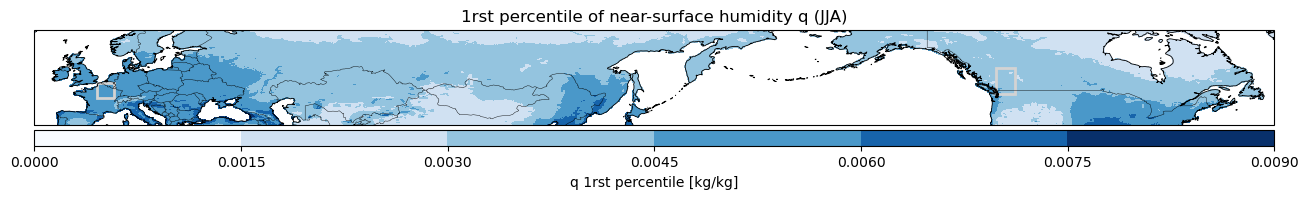

In [71]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_q_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_q_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_q_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# Read q quantile field
# -----------------------
if "q_quantiles" in dsq_band.data_vars:
    qQ = dsq_band["q_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 'q_quantiles' not found; using '{first_name}' instead.")
    qQ = dsq_band[first_name]

qQ = qQ.sortby("quantile").squeeze(drop=True)

# select percentile (change this as needed)
q90 = qQ.isel(quantile=0)

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

q90_land = q90.where(land_mask)

# -----------------------
# Plot (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = q90_land.plot(
    ax=ax, transform=data_crs,
    x="lon", y="lat",
    cmap="Blues", levels=8,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("1rst percentile of near-surface humidity q (JJA)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("q 1rst percentile [kg/kg]")

plt.savefig("q_p1_map.png", dpi=300, bbox_inches="tight")
plt.show()


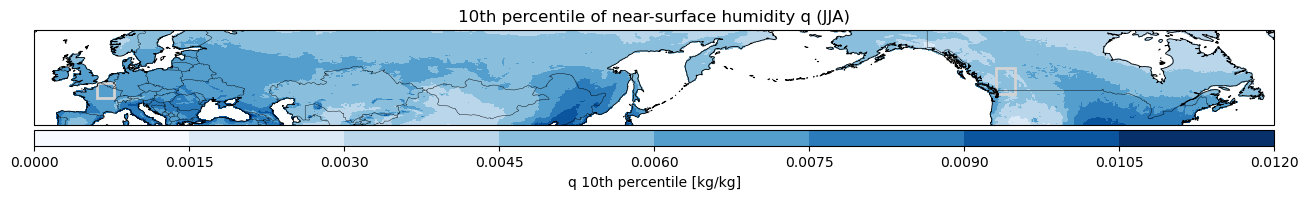

In [73]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_q_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_q_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_q_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# Read q quantile field
# -----------------------
if "q_quantiles" in dsq_band.data_vars:
    qQ = dsq_band["q_quantiles"]
else:
    first_name = list(dsq_band.data_vars)[0]
    print(f"WARNING: 'q_quantiles' not found; using '{first_name}' instead.")
    qQ = dsq_band[first_name]

qQ = qQ.sortby("quantile").squeeze(drop=True)

# select percentile (change this as needed)
q90 = qQ.isel(quantile=4)

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

q90_land = q90.where(land_mask)

# -----------------------
# Plot (horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = q90_land.plot(
    ax=ax, transform=data_crs,
    x="lon", y="lat",
    cmap="Blues", levels=8,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("10th percentile of near-surface humidity q (JJA)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("q 10th percentile [kg/kg]")

plt.savefig("q_p10_map.png", dpi=300, bbox_inches="tight")
plt.show()


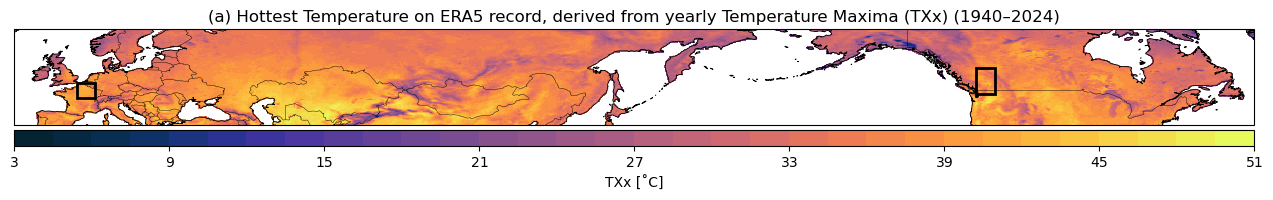

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# 1) Hottest TXX value per grid cell
# -----------------------
txx = ds_band["txx"] -273.15                # (year, lat, lon)
txx_hot = txx.max("year")            # (lat, lon)

# -----------------------
# 2) Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

txx_hot_land = txx_hot.where(land_mask)

# -----------------------
# 3) Plot (with horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

cmap = cmocean.cm.thermal

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = txx_hot_land.plot(
    ax=ax, transform=data_crs,
    x="lon", y="lat",
    cmap=cmap,
    levels=32,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="black", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="black", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("(a) Hottest Temperature on ERA5 record, derived from yearly Temperature Maxima (TXx) (1940–2024)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)

cbar.set_label("TXx [˚C]")

plt.savefig("txx_hottest_map.png", dpi=300, bbox_inches="tight")
plt.show()


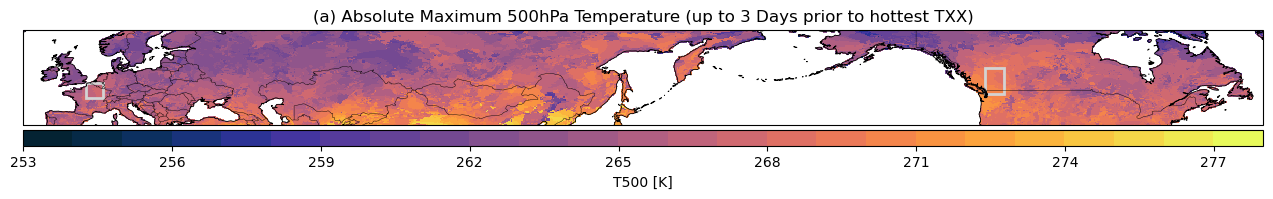

In [103]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"
path_t500_quant = "/work/uc1275/u301827/02_MSE/full_midlatitude/era5_midlatitudes_JJA_t500_daily_quantiles.nc"

# -----------------------
# Load datasets
# -----------------------
ds  = xr.open_dataset(path_txx)
dsq = xr.open_dataset(path_t500_quant)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118  # example: 235–245
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band  = sel_lat_band(ds,  lat_min, lat_max).sortby("lon")
dsq_band = sel_lat_band(dsq, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# 1) Hottest TXX year per grid cell
# -----------------------
txx = ds_band["txx"]                 # (year, lat, lon)
i_hot = txx.argmax("year")           # (lat, lon)

t500_hot = ds_band["t500_premax_3d"].isel(year=i_hot)  # (lat, lon)

# -----------------------
# 2) Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

t500_hot_land = t500_hot.where(land_mask)

# -----------------------
# 3) Plot absolute T500 values (with horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

cmap = cmocean.cm.thermal

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = t500_hot_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmap, levels=31,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("(a) Absolute Maximum 500hPa Temperature (up to 3 Days prior to hottest TXX)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)

cbar.set_label("T500 [K]")

plt.savefig("maxT500_absolute_TXX_map.png", dpi=300, bbox_inches="tight")
plt.show()


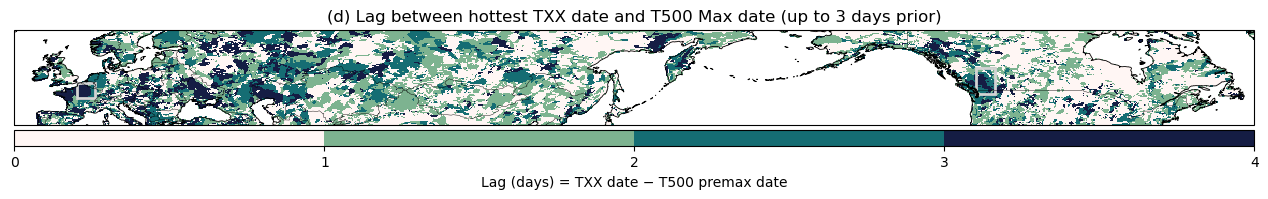

In [99]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# 1) Hottest TXX year per grid cell
# -----------------------
txx = ds_band["txx"]                 # (year, lat, lon)
i_hot = txx.argmax("year")           # (lat, lon)

# event dates at that hottest-TXX year (per grid cell)
d_txx  = ds_band["txx_yyyymmdd"].isel(year=i_hot)
d_t500 = ds_band["t500_premax_3d_yyyymmdd"].isel(year=i_hot)

# -----------------------
# 2) Convert YYYYMMDD -> datetime64 and compute lag in days
# -----------------------
def yyyymmdd_to_datetime64(da):
    # handles int/float/object; preserves (lat, lon)
    s = da.astype("int64").astype(str)
    return xr.apply_ufunc(
        pd.to_datetime,
        s,
        kwargs={"format": "%Y%m%d", "errors": "coerce"},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.dtype("datetime64[ns]")]
    )

dt_txx  = yyyymmdd_to_datetime64(d_txx)
dt_t500 = yyyymmdd_to_datetime64(d_t500)

# lag = txx_date - t500_date (positive means t500 occurs BEFORE txx)
lag_days = (dt_txx - dt_t500) / np.timedelta64(1, "D")
lag_days = lag_days.rename("lag_txx_minus_t500_days")
lag_days.attrs["description"] = "Lag in days: (txx date) - (t500 premax date); positive => t500 leads txx"

# -----------------------
# 3) Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)

lag_land = lag_days.where(land_mask)

# -----------------------
# 4) Plot lag (with horizontal colorbar below)
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

# (optional) fixed range since your t500 is "premax_3d" -> expect ~0..3 days
im = lag_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.tempo,
    vmin=0, vmax=4,
    levels=5,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lat0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectl)

ax.set_title("(d) Lag between hottest TXX date and T500 Max date (up to 3 days prior)")

# ---- Horizontal colorbar below plot ----
fig.subplots_adjust(bottom=0.22)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("Lag (days) = TXX date − T500 premax date")

plt.savefig("lag_txx_minus_t500_days.png", dpi=300, bbox_inches="tight")
plt.show()


In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

# -----------------------
# Load dataset
# -----------------------
ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band only (ENTIRE longitude band kept)
# -----------------------
lat_min, lat_max = 40.0, 65.0

# ---- BOX: larger Paris region (approx Île-de-France) ----
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# ---- BOX you want to draw (edit these) ----
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:  # descending
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:                 # ascending
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat',0)}, lon={ds_band.dims.get('lon',0)}"
    )

# -----------------------
# Convert YYYYMMDD -> datetime64 (works for (year,lat,lon))
# -----------------------
def yyyymmdd_to_datetime64(da):
    s = da.astype("int64").astype(str)
    return xr.apply_ufunc(
        pd.to_datetime,
        s,
        kwargs={"format": "%Y%m%d", "errors": "coerce"},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.dtype("datetime64[ns]")]
    )

# -----------------------
# 1) Lag for ALL years per grid cell
# -----------------------
d_txx_all  = ds_band["txx_yyyymmdd"]                 # (year, lat, lon)
d_t500_all = ds_band["t500_premax_3d_yyyymmdd"]      # (year, lat, lon)

dt_txx_all  = yyyymmdd_to_datetime64(d_txx_all)
dt_t500_all = yyyymmdd_to_datetime64(d_t500_all)

lag_days_all = (dt_txx_all - dt_t500_all) / np.timedelta64(1, "D")
lag_days_all = lag_days_all.rename("lag_txx_minus_t500_days")
lag_days_all.attrs["description"] = "Lag in days: (txx date) - (t500 premax date); positive => t500 leads txx"

# OPTIONAL: keep only expected range (since t500_premax_3d should be 0..3 days prior)
# comment out if you want to include weird cases too
lag_days_all = lag_days_all.where((lag_days_all >= 0) & (lag_days_all <= 4))

# -----------------------
# 2) Mean lag per grid cell over all years
# -----------------------
lag_mean = lag_days_all.mean("year", skipna=True).rename("mean_lag_days")

# -----------------------
# 3) Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = (land.mask(ds_band["lon"], ds_band["lat"]) == 0)
lag_mean_land = lag_mean.where(land_mask)

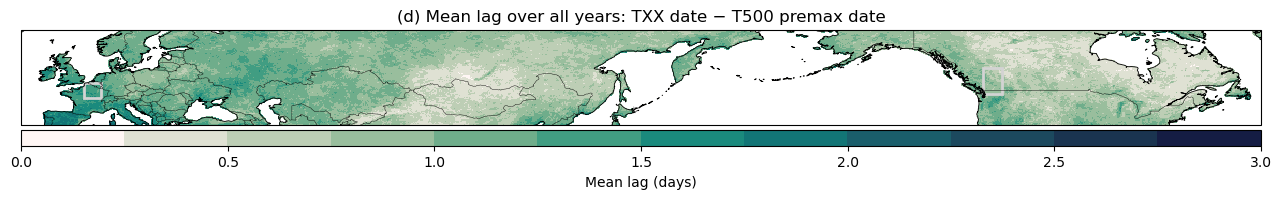

In [5]:
# -----------------------
# 4) Plot mean lag
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(16, 4))
ax = plt.axes(projection=proj)

ax.coastlines(linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, alpha=0.10)

im = lag_mean_land.plot(
    ax=ax, transform=data_crs, x="lon", y="lat",
    cmap=cmocean.cm.tempo,
    vmin=0, vmax=3,
    levels=13,
    add_colorbar=False
)

lonL, lonR = -15, 310
ax.set_extent([lonL, lonR, lat_min, lat_max], crs=data_crs)

# Draw rectangles
rectp = mpatches.Rectangle(
    (box_lon0p, box_lat0p),
    box_lon1p - box_lon0p,
    box_lat1p - box_lat0p,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
ax.add_patch(rectp)

rectl = mpatches.Rectangle(
    (box_lon0l, box_lat0l),
    box_lon1l - box_lon0l,
    box_lat1l - box_lon0l,
    fill=False, edgecolor="lightgray", linewidth=2,
    transform=data_crs,
)
# NOTE: typo fix: width should be (box_lon1l - box_lon0l) not (box_lon1l - box_lon0l) already
rectl.set_width(box_lon1l - box_lon0l)
rectl.set_height(box_lat1l - box_lat0l)
ax.add_patch(rectl)

ax.set_title("(d) Mean lag over all years: TXX date − T500 premax date")

fig.subplots_adjust(bottom=0.22)
cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    pad=0.02,
    fraction=0.06,
    aspect=80
)
cbar.set_label("Mean lag (days)")

plt.savefig("mean_lag_txx_minus_t500_days.png", dpi=300, bbox_inches="tight")
plt.show()


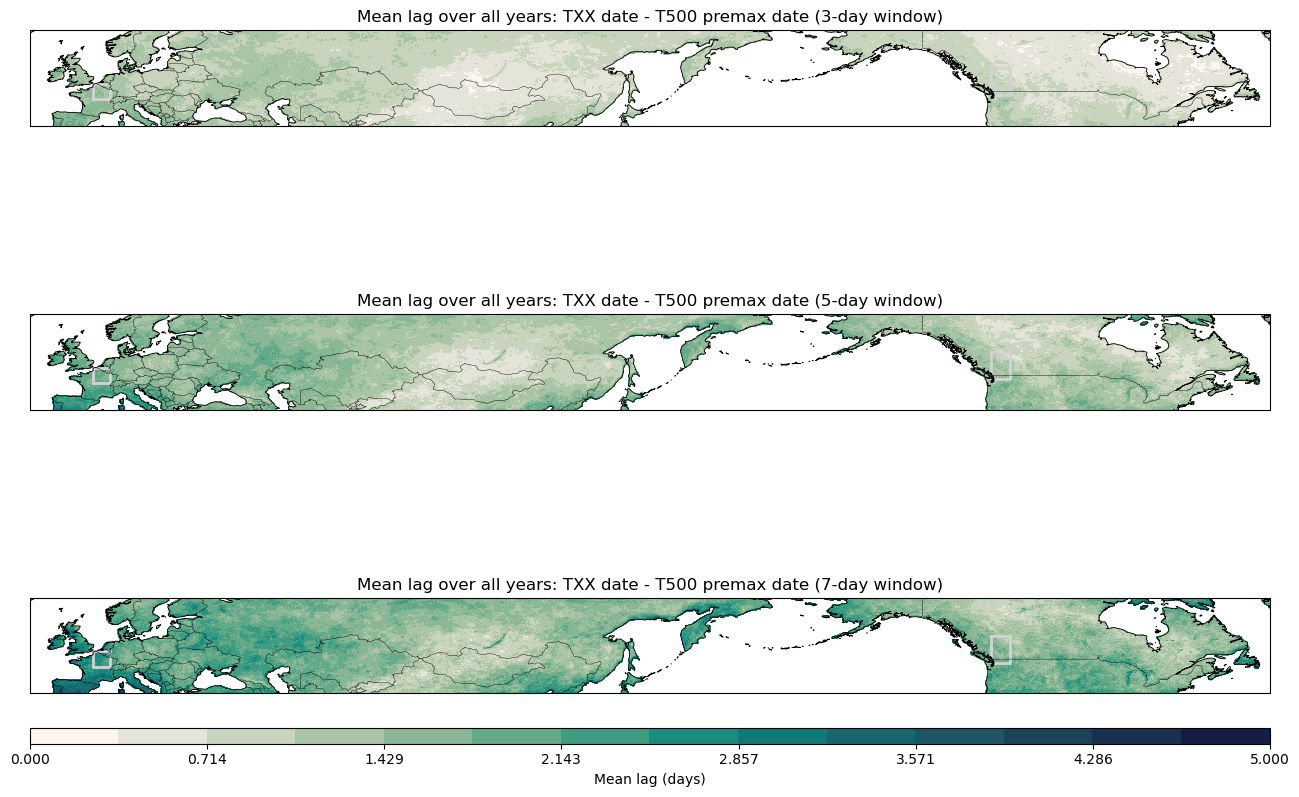

In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask
import matplotlib.patches as mpatches
import cmocean

# -----------------------
# Paths
# -----------------------
path_txx = "/work/uc1275/u301827/02_MSE/full_midlatitude/TXX/txx_at_tasmax_merged_1940_2024.nc"

ds = xr.open_dataset(path_txx)

# -----------------------
# Latitude band
# -----------------------
lat_min, lat_max = 40.0, 65.0

# Paris / Ile-de-France box
box_lon0p, box_lon1p = 1.5, 6
box_lat0p, box_lat1p = 47.0, 51.0

# West North America box
box_lon0l, box_lon1l = 360 - 123, 360 - 118
box_lat0l, box_lat1l = 48, 55

def sel_lat_band(ds_in, lat_min, lat_max, lat_name="lat"):
    lat = ds_in[lat_name]
    if lat[0] > lat[-1]:
        return ds_in.sel({lat_name: slice(lat_max, lat_min)})
    else:
        return ds_in.sel({lat_name: slice(lat_min, lat_max)})

ds_band = sel_lat_band(ds, lat_min, lat_max).sortby("lon")

if ds_band.dims.get("lat", 0) == 0 or ds_band.dims.get("lon", 0) == 0:
    raise ValueError(
        f"Band selection empty! lat={ds_band.dims.get('lat', 0)}, "
        f"lon={ds_band.dims.get('lon', 0)}"
    )

# -----------------------
# Convert YYYYMMDD -> datetime64
# -----------------------
def yyyymmdd_to_datetime64(da):
    s = da.astype("int64").astype(str)
    return xr.apply_ufunc(
        pd.to_datetime,
        s,
        kwargs={"format": "%Y%m%d", "errors": "coerce"},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[np.dtype("datetime64[ns]")]
    )

def yyyymmdd_to_datetime64_fast(da):
    vals = da.values.astype("int64")
    flat = vals.ravel().astype(str)
    
    dt = pd.to_datetime(flat, format="%Y%m%d", errors="coerce").values
    dt = dt.reshape(vals.shape)

    return xr.DataArray(dt, coords=da.coords, dims=da.dims)

# -----------------------
# Land mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = land.mask(ds_band["lon"], ds_band["lat"]) == 0

# -----------------------
# Plot settings
# -----------------------
cases = {
    3: "t500_premax_3d_yyyymmdd",
    5: "t500_premax_5d_yyyymmdd",
    7: "t500_premax_7d_yyyymmdd",
}

proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 10),
    subplot_kw={"projection": proj},
    constrained_layout=False,
)

d_txx_all = ds_band["txx_yyyymmdd"]
dt_txx_all = yyyymmdd_to_datetime64_fast(d_txx_all)

im = None

# Shared color scale for all panels
vmin_common = 0
vmax_common = 5
levels_common = np.linspace(vmin_common, vmax_common, 15)

im = None

for ax, (ndays, varname) in zip(axes, cases.items()):
    if varname not in ds_band:
        raise KeyError(f"Missing variable in dataset: {varname}")

    d_t500_all = ds_band[varname]
    dt_t500_all = yyyymmdd_to_datetime64_fast(d_t500_all)

    lag_days_all = (dt_txx_all - dt_t500_all) / np.timedelta64(1, "D")
    lag_days_all = lag_days_all.rename(f"lag_txx_minus_t500_{ndays}d")

    # Expected range: 0..ndays if include_txx_day=True
    lag_days_all = lag_days_all.where(
        (lag_days_all >= 0) & (lag_days_all <= ndays)
    )

    lag_mean = lag_days_all.mean("year", skipna=True).rename(f"mean_lag_{ndays}d")
    lag_mean_land = lag_mean.where(land_mask)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    im = lag_mean_land.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap=cmocean.cm.tempo,
        vmin=vmin_common,
        vmax=vmax_common,
        levels=levels_common,
        add_colorbar=False,
    )

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    rectp = mpatches.Rectangle(
        (box_lon0p, box_lat0p),
        box_lon1p - box_lon0p,
        box_lat1p - box_lat0p,
        fill=False,
        edgecolor="lightgray",
        linewidth=2,
        transform=data_crs,
    )
    ax.add_patch(rectp)

    rectl = mpatches.Rectangle(
        (box_lon0l, box_lat0l),
        box_lon1l - box_lon0l,
        box_lat1l - box_lat0l,
        fill=False,
        edgecolor="lightgray",
        linewidth=2,
        transform=data_crs,
    )
    ax.add_patch(rectl)

    ax.set_title(
        f"Mean lag over all years: TXX date - T500 premax date ({ndays}-day window)"
    )

fig.subplots_adjust(bottom=0.08, top=0.95, hspace=0.22)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.04,
    fraction=0.04,
    aspect=80,
)
cbar.set_label("Mean lag (days)")

plt.savefig("mean_lag_txx_minus_t500_days_3d_5d_7d.png", dpi=300, bbox_inches="tight")
plt.show()

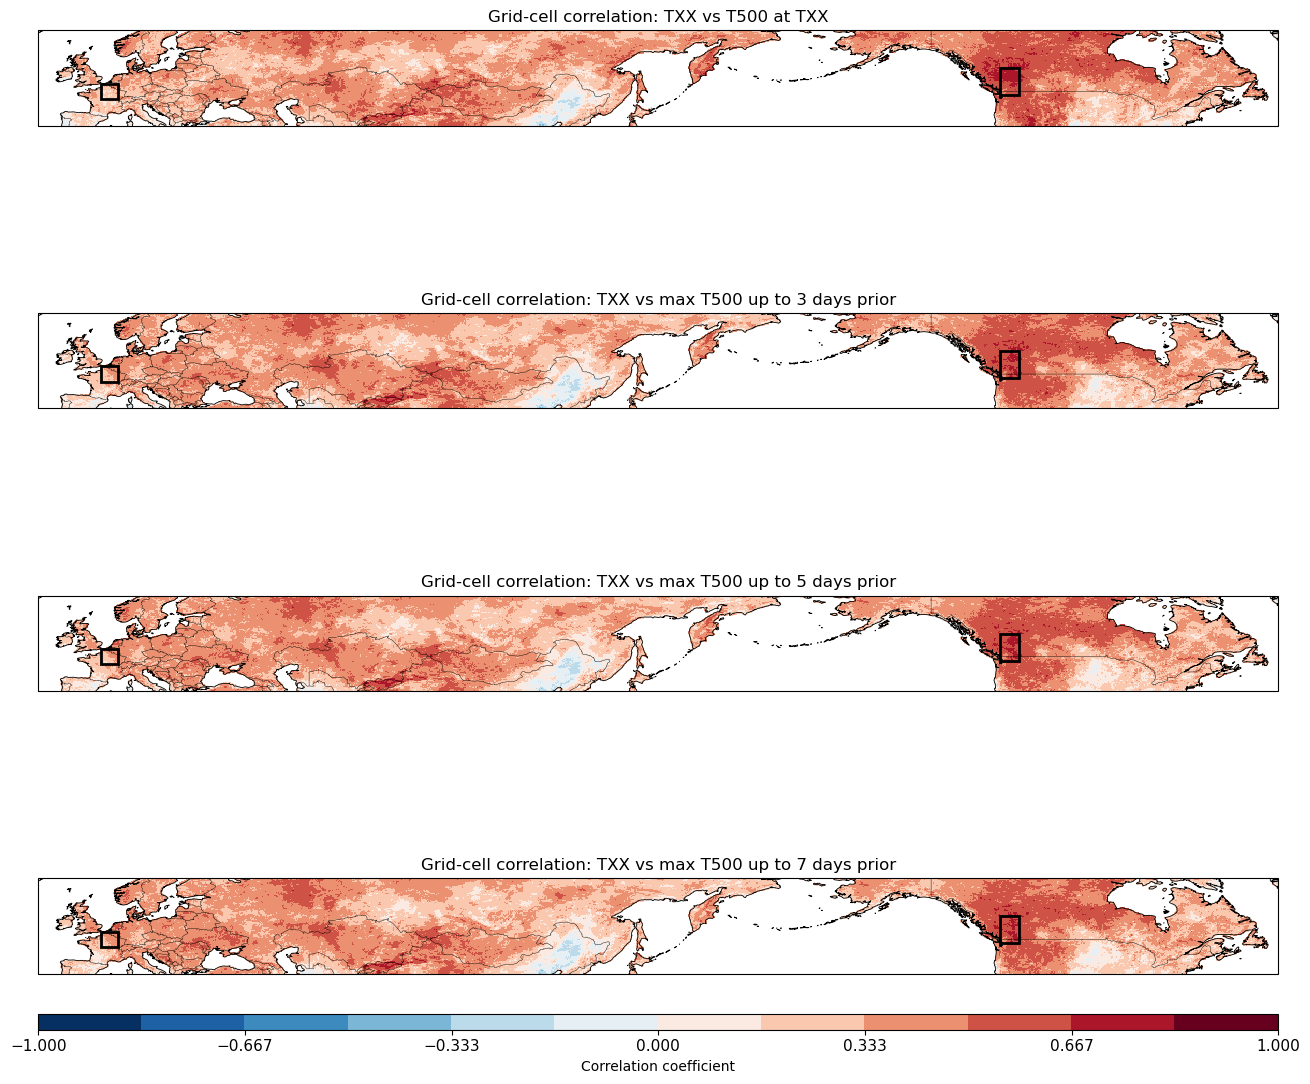

In [8]:
# -----------------------
# Plot cases
# -----------------------
cases = [
    ("T500 at TXX", "t_at_tasmax"),
    ("max T500 up to 3 days prior", "t500_premax_3d"),
    ("max T500 up to 5 days prior", "t500_premax_5d"),
    ("max T500 up to 7 days prior", "t500_premax_7d"),
]

# -----------------------
# Require at least N valid years per grid cell
# -----------------------
min_n = 20

# -----------------------
# Land-only mask
# -----------------------
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
land_mask = land.mask(ds_band["lon"], ds_band["lat"]) == 0

# -----------------------
# Projection
# -----------------------
proj = ccrs.PlateCarree(central_longitude=135)
data_crs = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(16, 13),
    subplot_kw={"projection": proj},
    constrained_layout=False,
)

# -----------------------
# Boxes
# -----------------------
lon0_1, lon1_1 = 1.5, 6
lat0_1, lat1_1 = 47.0, 51.0

lon0_2, lon1_2 = 360 - 123, 360 - 118
lat0_2, lat1_2 = 48, 55

im = None

for ax, (label, varname) in zip(axes, cases):
    if varname not in ds_band:
        raise KeyError(f"Missing variable in dataset: {varname}")

    txx = ds_band["txx"]
    xvar = ds_band[varname]

    txx, xvar = xr.align(txx, xvar, join="inner")

    nvalid = (np.isfinite(txx) & np.isfinite(xvar)).sum("year")

    txx_valid = txx.where(nvalid >= min_n)
    xvar_valid = xvar.where(nvalid >= min_n)

    r = xr.corr(txx_valid, xvar_valid, dim="year")
    r_land = r.where(land_mask)

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.LAND, alpha=0.10)

    ax.set_extent([-15, 310, lat_min, lat_max], crs=data_crs)

    im = r_land.plot(
        ax=ax,
        transform=data_crs,
        x="lon",
        y="lat",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        levels=13,
        add_colorbar=False,
    )

    rect1 = mpatches.Rectangle(
        (lon0_1, lat0_1),
        lon1_1 - lon0_1,
        lat1_1 - lat0_1,
        linewidth=2,
        edgecolor="black",
        facecolor="none",
        transform=data_crs,
        zorder=6,
    )
    ax.add_patch(rect1)

    rect2 = mpatches.Rectangle(
        (lon0_2, lat0_2),
        lon1_2 - lon0_2,
        lat1_2 - lat0_2,
        linewidth=2,
        edgecolor="black",
        facecolor="none",
        transform=data_crs,
        zorder=6,
    )
    ax.add_patch(rect2)

    ax.set_title(f"Grid-cell correlation: TXX vs {label}")

fig.subplots_adjust(bottom=0.07, top=0.96, hspace=0.24)

cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    pad=0.035,
    fraction=0.035,
    aspect=80,
)
cbar.set_label("Correlation coefficient")
cbar.ax.tick_params(labelsize=11)

plt.savefig(
    "t500_at_txx_and_t500premax_3d_5d_7d_vs_TXX_correlation_maps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()